# 中芯国际 H 股技术指标分析

本 Notebook 使用中芯国际 H 股（`00981.HK`）的未复权日线行情，逐步计算 RSI、MACD、布林带和 ATR。

- **分析区间：** 2025-07-02 至 2026-06-30
- **数据来源：** Tushare Pro `hk_daily`
- **价格币种：** 港元
- **说明：** 内容仅用于课程学习与数据分析，不构成投资建议。

执行顺序为：配置 → 数据获取与清洗 → 公式说明 → 指标计算 → 验证 → 可视化 → 结果总结。

## 1. 环境与集中配置

运行环境需要 `pandas`、`numpy`、`matplotlib`、`tushare`、`python-dotenv` 和 Jupyter。Notebook 会从项目根目录的 `.env` 加载 `TUSHARE_TOKEN`，不会在输出或缓存中显示 Token。

默认优先读取本地缓存。需要重新下载时，将 `REFRESH_DATA` 改为 `True`。

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import font_manager
from dotenv import load_dotenv
from IPython.display import display

load_dotenv()

plt.style.use("seaborn-v0_8-whitegrid")

# 优先注册 macOS 自带中文字体，再回退到其他平台的常见中文字体
for font_path in [
    Path("/System/Library/Fonts/STHeiti Medium.ttc"),
    Path("/System/Library/Fonts/STHeiti Light.ttc"),
]:
    if font_path.exists():
        font_manager.fontManager.addfont(font_path)
plt.rcParams["font.sans-serif"] = [
    "Heiti TC", "PingFang SC", "Microsoft YaHei", "SimHei", "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False

# 数据配置
TS_CODE = "00981.HK"
START_DATE = "20250702"
END_DATE = "20260630"
REFRESH_DATA = False
CACHE_PATH = Path("data/00981_HK_daily_20250702_20260630.csv")

# 指标配置
RSI_PERIOD = 14
MACD_FAST = 12
MACD_SLOW = 26
MACD_SIGNAL = 9
BB_PERIOD = 20
BB_STD_MULTIPLIER = 2.0
ATR_PERIOD = 14
RSI_COLUMN = f"rsi_{RSI_PERIOD}"
ATR_COLUMN = f"atr_{ATR_PERIOD}"

print(f"证券：{TS_CODE} | 区间：{START_DATE}–{END_DATE}")
print(f"缓存：{CACHE_PATH} | 强制刷新：{REFRESH_DATA}")

证券：00981.HK | 区间：20250702–20260630
缓存：data/00981_HK_daily_20250702_20260630.csv | 强制刷新：False


## 2. 获取、清洗并验证行情

`load_price_data` 的行为：

1. 缓存存在且未要求刷新时，直接读取缓存。
2. 否则从环境变量读取 Token，并调用 Tushare `hk_daily`。
3. 将 `vol`/`volume` 统一为 `volume`，把日期升序排列并检查 OHLCV。
4. 接口成功后写入 CSV 缓存，之后可以离线复现。

如果没有缓存且 Token 缺失或无港股日线权限，本节会给出明确提示，后面的公式和人工样例测试仍可运行。

In [2]:
class DataLoadError(RuntimeError):
    """行情不可用时抛出的可读错误。"""


def _clean_price_data(raw, start_date, end_date):
    """统一字段、数据类型、排序和基础行情约束。"""
    if raw is None or raw.empty:
        raise DataLoadError("行情为空，请检查证券代码、日期区间和接口权限。")

    data = raw.copy()
    if "volume" not in data.columns and "vol" in data.columns:
        data = data.rename(columns={"vol": "volume"})

    required = ["trade_date", "open", "high", "low", "close", "volume"]
    missing = [column for column in required if column not in data.columns]
    if missing:
        raise DataLoadError(f"行情缺少必需字段：{missing}")

    data["trade_date"] = pd.to_datetime(data["trade_date"], errors="coerce")
    numeric_columns = ["open", "high", "low", "close", "volume"]
    optional_numeric = ["pre_close", "change", "pct_chg", "amount"]
    for column in numeric_columns + [c for c in optional_numeric if c in data.columns]:
        data[column] = pd.to_numeric(data[column], errors="coerce")

    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    data = data.loc[data["trade_date"].between(start, end)].copy()
    data = data.drop_duplicates(subset="trade_date", keep="last")
    data = data.sort_values("trade_date").reset_index(drop=True)

    if data.empty:
        raise DataLoadError("指定日期区间内没有行情数据。")
    if data[required].isna().any().any():
        bad = data.loc[data[required].isna().any(axis=1), "trade_date"].dt.strftime("%Y-%m-%d").tolist()
        raise DataLoadError(f"必需字段存在空值或非法值，相关日期：{bad[:5]}")

    invalid_ohlc = (
        (data["high"] < data["low"])
        | (data["open"] > data["high"])
        | (data["open"] < data["low"])
        | (data["close"] > data["high"])
        | (data["close"] < data["low"])
    )
    if invalid_ohlc.any():
        dates = data.loc[invalid_ohlc, "trade_date"].dt.strftime("%Y-%m-%d").tolist()
        raise DataLoadError(f"OHLC 价格关系不合法，相关日期：{dates[:5]}")
    if (data["volume"] < 0).any():
        raise DataLoadError("成交量存在负值。")

    return data


def load_price_data(ts_code, start_date, end_date, cache_path, refresh=False):
    """从本地缓存或 Tushare 读取未复权港股日线，返回 (DataFrame, 来源说明)。"""
    cache_path = Path(cache_path)

    if cache_path.exists() and not refresh:
        try:
            raw = pd.read_csv(cache_path)
        except Exception as exc:
            raise DataLoadError(f"缓存读取失败：{exc}") from exc
        source = f"本地缓存：{cache_path}"
    else:
        token = os.getenv("TUSHARE_TOKEN")
        if not token:
            raise DataLoadError(
                "未找到缓存且环境变量 TUSHARE_TOKEN 未设置。请先在运行环境中设置 Token，"
                "并确认账户拥有 hk_daily 权限，然后重新执行。"
            )
        try:
            import tushare as ts
        except ImportError as exc:
            raise DataLoadError("缺少 tushare，请先安装：pip install tushare") from exc

        try:
            pro = ts.pro_api(token)
            raw = pro.hk_daily(ts_code=ts_code, start_date=start_date, end_date=end_date)
        except Exception as exc:
            raise DataLoadError(
                f"Tushare hk_daily 调用失败，请检查网络、Token 和港股日线权限。原始信息：{exc}"
            ) from exc

        if raw is None or raw.empty:
            raise DataLoadError("Tushare 返回空行情，请检查代码、日期与接口权限。")
        source = "Tushare Pro hk_daily（未复权）"

    data = _clean_price_data(raw, start_date, end_date)

    if source.startswith("Tushare"):
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        to_cache = data.copy()
        to_cache["trade_date"] = to_cache["trade_date"].dt.strftime("%Y-%m-%d")
        to_cache.to_csv(cache_path, index=False, encoding="utf-8-sig")

    return data, source

In [3]:
price_data = None
data_source = None
data_error = None

try:
    price_data, data_source = load_price_data(
        TS_CODE, START_DATE, END_DATE, CACHE_PATH, refresh=REFRESH_DATA
    )
    print(f"数据来源：{data_source}")
    print(
        f"样本：{len(price_data)} 个交易日 | "
        f"{price_data['trade_date'].min():%Y-%m-%d} 至 {price_data['trade_date'].max():%Y-%m-%d}"
    )
    display(price_data.head())
    display(price_data.tail())
except DataLoadError as exc:
    data_error = str(exc)
    print("数据加载未完成：")
    print(data_error)
    print("已跳过依赖真实行情的计算与图表；公式定义和人工样例测试将继续执行。")

数据来源：本地缓存：data/00981_HK_daily_20250702_20260630.csv
样本：245 个交易日 | 2025-07-02 至 2026-06-30


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,volume,amount
0,00981.HK,2025-07-02,45.15,45.40,43.15,43.55,44.70,-1.15,-2.57,89397299.0,3.924170e+09
1,00981.HK,2025-07-03,43.65,44.65,43.15,43.30,43.55,-0.25,-0.57,78532958.0,3.435377e+09
2,00981.HK,2025-07-04,43.10,44.80,41.50,43.95,43.30,0.65,1.50,124680391.0,5.392125e+09
3,00981.HK,2025-07-07,44.30,45.00,43.70,44.30,43.95,0.35,0.80,58889473.0,2.606607e+09
4,00981.HK,2025-07-08,44.65,45.90,44.45,45.65,44.30,1.35,3.05,68833165.0,3.113079e+09


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,volume,amount
240,00981.HK,2026-06-24,77.60,86.45,77.60,84.8,77.85,6.95,8.93,218098916.0,1.824135e+10
241,00981.HK,2026-06-25,87.40,88.70,83.80,86.0,84.80,1.20,1.42,127969567.0,1.104846e+10
242,00981.HK,2026-06-26,84.50,85.25,79.05,80.0,86.00,-6.00,-6.98,142920129.0,1.160892e+10
243,00981.HK,2026-06-29,79.55,85.80,79.35,84.8,80.00,4.80,6.00,124513219.0,1.028133e+10
244,00981.HK,2026-06-30,84.60,91.55,84.25,89.4,84.80,4.60,5.42,176623921.0,1.576798e+10


## 3. 指标公式

### 3.1 RSI(14)

先计算收盘价变化：

\[
\Delta_t = Close_t - Close_{t-1},\quad
Gain_t=\max(\Delta_t,0),\quad Loss_t=\max(-\Delta_t,0)
\]

第一个平均上涨量和平均下跌量使用 14 期简单平均，后续使用 Wilder 递推：

\[
Avg_t=\frac{Avg_{t-1}\times(14-1)+Value_t}{14},\quad
RSI_t=100-\frac{100}{1+AvgGain_t/AvgLoss_t}
\]

### 3.2 MACD(12, 26, 9)

\[
MACD_t=EMA_{12}(Close)_t-EMA_{26}(Close)_t
\]

\[
Signal_t=EMA_9(MACD)_t,\quad Histogram_t=MACD_t-Signal_t
\]

### 3.3 布林带(20, 2)

\[
Middle_t=SMA_{20}(Close)_t
\]

\[
Upper_t=Middle_t+2\sigma_{20,t},\quad Lower_t=Middle_t-2\sigma_{20,t}
\]

标准差使用总体标准差（`ddof=0`）。

### 3.4 ATR(14)

\[
TR_t=\max\left(High_t-Low_t, |High_t-Close_{t-1}|, |Low_t-Close_{t-1}|\right)
\]

首个 ATR 为 14 个 TR 的简单平均，之后按 Wilder 方法递推。ATR 衡量波动幅度，不表示价格方向。

In [4]:
def calculate_rsi(close, period=14):
    """使用首期简单平均 + Wilder 递推计算 RSI。"""
    close = pd.Series(close, dtype="float64")
    delta = close.diff()
    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)

    avg_gain = pd.Series(np.nan, index=close.index, dtype="float64")
    avg_loss = pd.Series(np.nan, index=close.index, dtype="float64")

    if len(close) > period:
        avg_gain.iloc[period] = gains.iloc[1 : period + 1].mean()
        avg_loss.iloc[period] = losses.iloc[1 : period + 1].mean()
        for position in range(period + 1, len(close)):
            avg_gain.iloc[position] = (
                avg_gain.iloc[position - 1] * (period - 1) + gains.iloc[position]
            ) / period
            avg_loss.iloc[position] = (
                avg_loss.iloc[position - 1] * (period - 1) + losses.iloc[position]
            ) / period

    rsi = pd.Series(np.nan, index=close.index, dtype="float64", name=f"rsi_{period}")
    valid = avg_gain.notna() & avg_loss.notna()
    normal = valid & (avg_loss > 0)
    rs = avg_gain.loc[normal] / avg_loss.loc[normal]
    rsi.loc[normal] = 100 - 100 / (1 + rs)
    rsi.loc[valid & (avg_loss == 0) & (avg_gain > 0)] = 100.0
    rsi.loc[valid & (avg_loss == 0) & (avg_gain == 0)] = 50.0
    return rsi


def calculate_macd(close, fast=12, slow=26, signal=9):
    """使用 adjust=False 的 EMA 计算 MACD、信号线和柱状图。"""
    close = pd.Series(close, dtype="float64")
    ema_fast = close.ewm(span=fast, adjust=False, min_periods=fast).mean()
    ema_slow = close.ewm(span=slow, adjust=False, min_periods=slow).mean()
    macd = (ema_fast - ema_slow).rename("macd")
    macd_signal = macd.ewm(span=signal, adjust=False, min_periods=signal).mean().rename("macd_signal")
    macd_hist = (macd - macd_signal).rename("macd_hist")
    return pd.concat([macd, macd_signal, macd_hist], axis=1)


def calculate_bollinger_bands(close, period=20, std_multiplier=2.0):
    """使用滚动均值和总体标准差计算布林带。"""
    close = pd.Series(close, dtype="float64")
    middle = close.rolling(period, min_periods=period).mean().rename("bb_mid")
    rolling_std = close.rolling(period, min_periods=period).std(ddof=0)
    upper = (middle + std_multiplier * rolling_std).rename("bb_upper")
    lower = (middle - std_multiplier * rolling_std).rename("bb_lower")
    return pd.concat([middle, upper, lower], axis=1)


def calculate_atr(data, period=14):
    """计算 TR，并使用首期简单平均 + Wilder 递推得到 ATR。"""
    previous_close = data["close"].shift(1)
    components = pd.concat(
        [
            data["high"] - data["low"],
            (data["high"] - previous_close).abs(),
            (data["low"] - previous_close).abs(),
        ],
        axis=1,
    )
    tr = components.max(axis=1, skipna=True).rename("tr")
    atr = pd.Series(np.nan, index=data.index, dtype="float64", name=f"atr_{period}")

    if len(data) >= period:
        atr.iloc[period - 1] = tr.iloc[:period].mean()
        for position in range(period, len(data)):
            atr.iloc[position] = (atr.iloc[position - 1] * (period - 1) + tr.iloc[position]) / period

    return pd.concat([tr, atr], axis=1)

In [5]:
indicator_data = None

if price_data is not None:
    indicator_data = price_data.copy()
    indicator_data[RSI_COLUMN] = calculate_rsi(
        indicator_data["close"], RSI_PERIOD
    )
    indicator_data = pd.concat(
        [
            indicator_data,
            calculate_macd(indicator_data["close"], MACD_FAST, MACD_SLOW, MACD_SIGNAL),
            calculate_bollinger_bands(
                indicator_data["close"], BB_PERIOD, BB_STD_MULTIPLIER
            ),
            calculate_atr(indicator_data, ATR_PERIOD),
        ],
        axis=1,
    )
    print("指标计算完成。末 5 行：")
    display(indicator_data.tail())
else:
    print("没有真实行情，已跳过指标批量计算。")

指标计算完成。末 5 行：


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,volume,amount,rsi_14,macd,macd_signal,macd_hist,bb_mid,bb_upper,bb_lower,tr,atr_14
240,00981.HK,2026-06-24,77.60,86.45,77.60,84.8,77.85,6.95,8.93,218098916.0,1.824135e+10,62.251168,1.486001,1.245304,0.240698,78.2925,87.602456,68.982544,8.85,5.777101
241,00981.HK,2026-06-25,87.40,88.70,83.80,86.0,84.80,1.20,1.42,127969567.0,1.104846e+10,63.491130,2.033670,1.402977,0.630693,78.3325,87.766867,68.898133,4.90,5.714451
242,00981.HK,2026-06-26,84.50,85.25,79.05,80.0,86.00,-6.00,-6.98,142920129.0,1.160892e+10,53.949042,1.960947,1.514571,0.446376,77.9200,86.239339,69.600661,6.95,5.802705
243,00981.HK,2026-06-29,79.55,85.80,79.35,84.8,80.00,4.80,6.00,124513219.0,1.028133e+10,59.228203,2.264529,1.664563,0.599967,78.0800,86.790189,69.369811,6.45,5.848940
244,00981.HK,2026-06-30,84.60,91.55,84.25,89.4,84.80,4.60,5.42,176623921.0,1.576798e+10,63.541650,2.843524,1.900355,0.943169,78.5775,88.584022,68.570978,7.30,5.952587


## 4. 程序化验证与人工样例

第一部分验证真实结果的范围、恒等式和预热期。第二部分使用小型人工数据验证 Wilder 初始简单平均、递推公式和 TR 定义；人工测试不依赖 Tushare。

In [6]:
def validate_indicator_data(data):
    """验证基础行情与指标不变量；失败时抛出 AssertionError。"""
    assert data["trade_date"].is_monotonic_increasing, "日期未按升序排列"
    assert data["trade_date"].is_unique, "交易日存在重复"
    assert (data["volume"] >= 0).all(), "成交量存在负值"

    rsi = data[RSI_COLUMN].dropna()
    assert rsi.between(0, 100).all(), "RSI 超出 0–100"

    bands = data[["bb_upper", "bb_mid", "bb_lower"]].dropna()
    assert (bands["bb_upper"] >= bands["bb_mid"]).all(), "布林带上轨低于中轨"
    assert (bands["bb_mid"] >= bands["bb_lower"]).all(), "布林带中轨低于下轨"
    assert (data[ATR_COLUMN].dropna() >= 0).all(), "ATR 存在负值"

    macd_valid = data[["macd", "macd_signal", "macd_hist"]].dropna()
    assert np.allclose(
        macd_valid["macd_hist"],
        macd_valid["macd"] - macd_valid["macd_signal"],
        rtol=1e-12,
        atol=1e-12,
    ), "MACD 柱不等于 MACD 减信号线"

    assert data[RSI_COLUMN].iloc[:RSI_PERIOD].isna().all(), "RSI 预热期不正确"
    assert data["bb_mid"].iloc[: BB_PERIOD - 1].isna().all(), "布林带预热期不正确"
    assert data[ATR_COLUMN].iloc[: ATR_PERIOD - 1].isna().all(), "ATR 预热期不正确"
    assert data["macd"].iloc[: MACD_SLOW - 1].isna().all(), "MACD 预热期不正确"
    return True


if indicator_data is not None:
    validate_indicator_data(indicator_data)
    print("真实行情与指标验证：全部通过。")
else:
    print("没有真实行情，跳过真实结果验证。")

真实行情与指标验证：全部通过。


In [7]:
# RSI 人工样例：周期取 3，便于逐项核对
sample_close = pd.Series([10, 11, 10, 12, 11, 13], dtype="float64")
sample_rsi = calculate_rsi(sample_close, period=3)

# 初始：平均上涨=(1+0+2)/3=1，平均下跌=(0+1+0)/3=1/3，RSI=75
assert np.isclose(sample_rsi.iloc[3], 75.0)
# 下一期 Wilder 递推后 RSI = 54.54545...
assert np.isclose(sample_rsi.iloc[4], 54.54545454545455)
# 再下一期 Wilder 递推后 RSI = 75
assert np.isclose(sample_rsi.iloc[5], 75.0)

# ATR 人工样例：TR 应为 [2, 3, 2, 4]；周期 3 的首个 ATR=7/3，下一期=26/9
sample_ohlc = pd.DataFrame(
    {
        "high": [10, 12, 11, 14],
        "low": [8, 9, 9, 10],
        "close": [9, 10, 10, 13],
    },
    dtype="float64",
)
sample_atr = calculate_atr(sample_ohlc, period=3)
assert np.allclose(sample_atr["tr"], [2, 3, 2, 4])
assert np.isclose(sample_atr["atr_3"].iloc[2], 7 / 3)
assert np.isclose(sample_atr["atr_3"].iloc[3], 26 / 9)

print("人工样例测试：RSI 初始平均、Wilder 递推、TR 与 ATR 全部通过。")
display(pd.DataFrame({"close": sample_close, "rsi_3": sample_rsi}))
display(sample_atr)

人工样例测试：RSI 初始平均、Wilder 递推、TR 与 ATR 全部通过。


,close,rsi_3
0,10.0,NaN
1,11.0,NaN
2,10.0,NaN
3,12.0,75.000000
4,11.0,54.545455
5,13.0,75.000000


,tr,atr_3
0,2.0,NaN
1,3.0,NaN
2,2.0,2.333333
3,4.0,2.888889


## 5. 四类指标可视化

四个子图共享交易日期轴。布林带用于描述价格相对近期均值和波动区间；RSI 用于观察相对动能；MACD 展示快慢趋势差异；ATR 只反映波动幅度。

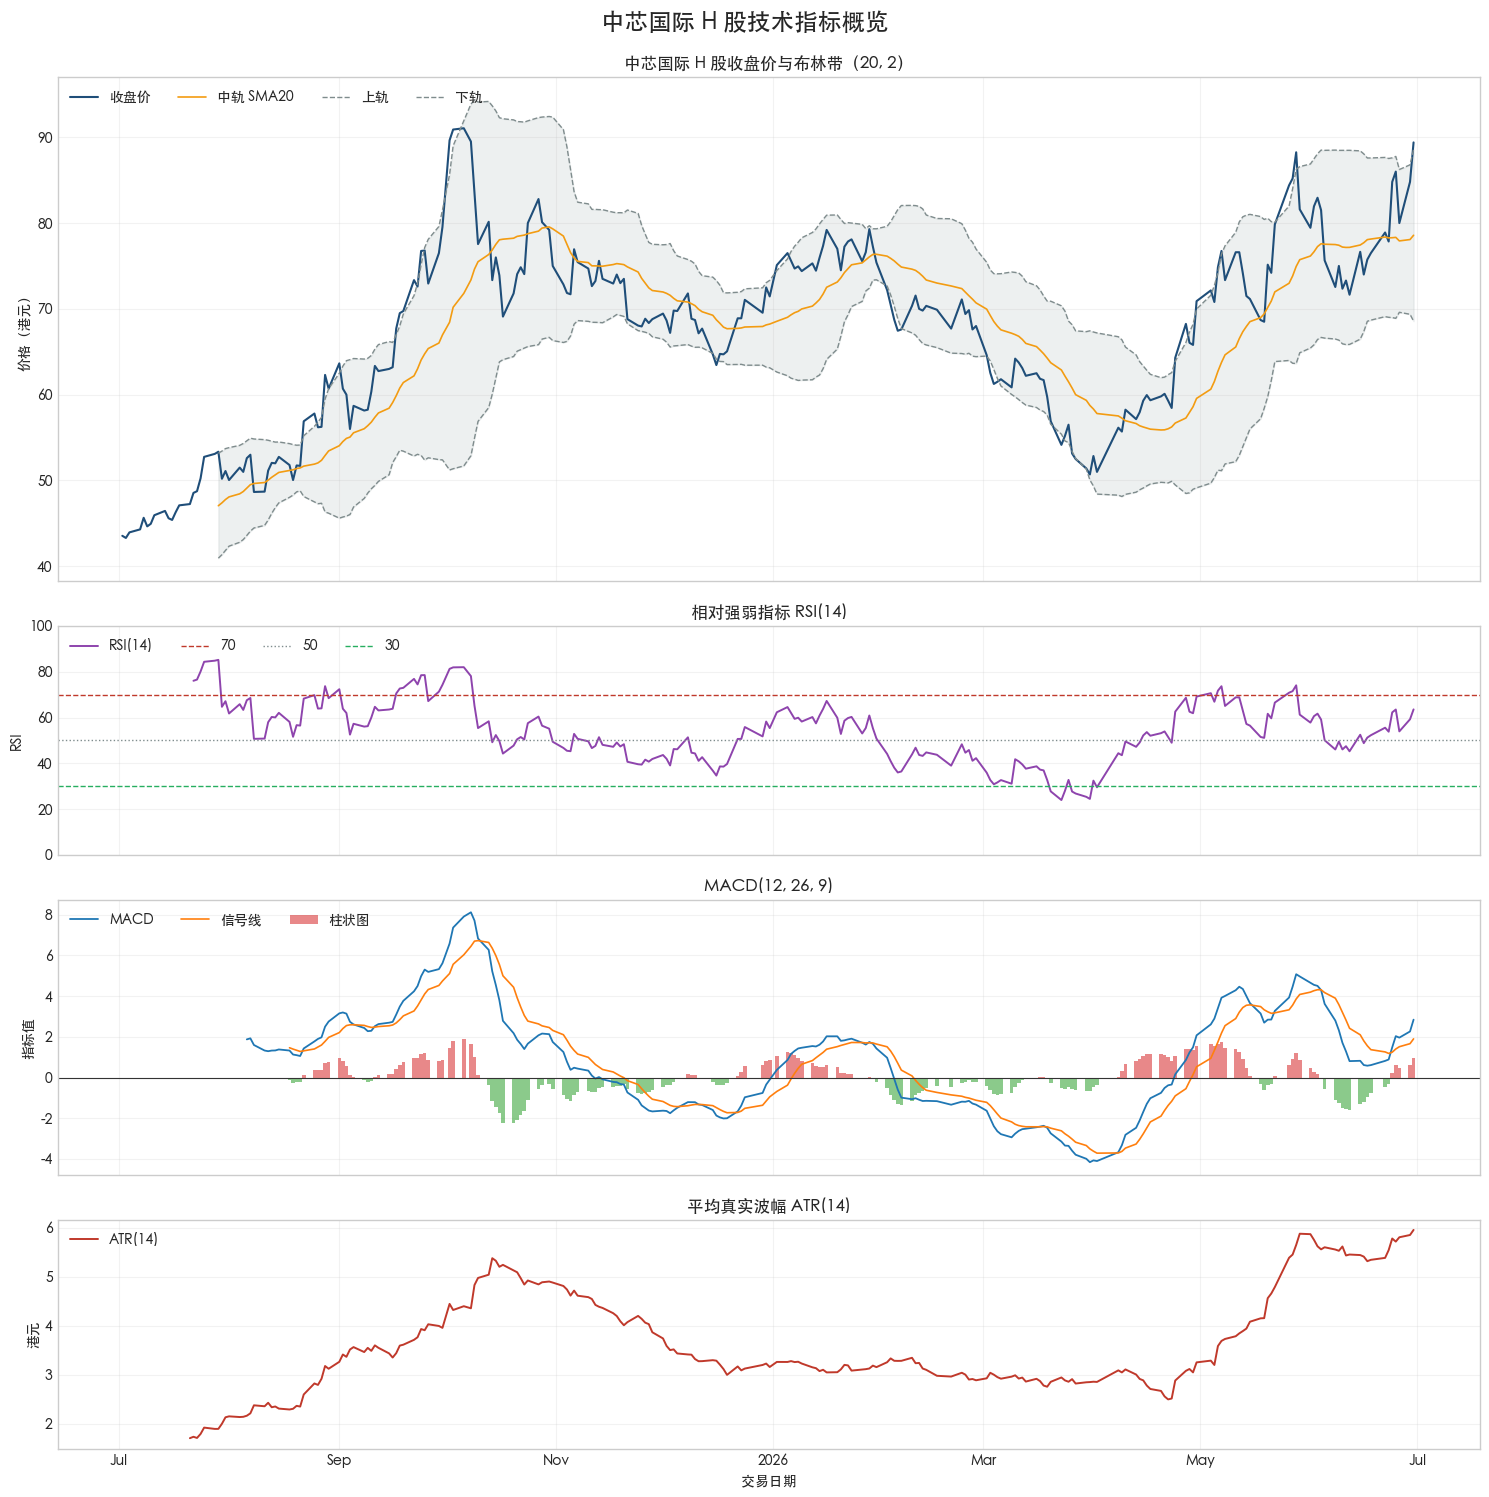

In [8]:
if indicator_data is not None:
    dates = indicator_data["trade_date"]
    fig, axes = plt.subplots(
        4, 1, figsize=(15, 15), sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1, 1.2, 1]},
    )

    # 收盘价与布林带
    axes[0].plot(dates, indicator_data["close"], color="#1f4e79", lw=1.5, label="收盘价")
    axes[0].plot(dates, indicator_data["bb_mid"], color="#f39c12", lw=1.2, label="中轨 SMA20")
    axes[0].plot(dates, indicator_data["bb_upper"], color="#7f8c8d", lw=1, ls="--", label="上轨")
    axes[0].plot(dates, indicator_data["bb_lower"], color="#7f8c8d", lw=1, ls="--", label="下轨")
    axes[0].fill_between(
        dates,
        indicator_data["bb_lower"].to_numpy(),
        indicator_data["bb_upper"].to_numpy(),
        color="#95a5a6", alpha=0.16,
    )
    axes[0].set_title("中芯国际 H 股收盘价与布林带（20, 2）")
    axes[0].set_ylabel("价格（港元）")
    axes[0].legend(loc="upper left", ncol=4)

    # RSI
    axes[1].plot(dates, indicator_data[RSI_COLUMN], color="#8e44ad", lw=1.4, label=f"RSI({RSI_PERIOD})")
    axes[1].axhline(70, color="#c0392b", ls="--", lw=1, label="70")
    axes[1].axhline(50, color="#7f8c8d", ls=":", lw=1, label="50")
    axes[1].axhline(30, color="#27ae60", ls="--", lw=1, label="30")
    axes[1].set_ylim(0, 100)
    axes[1].set_title("相对强弱指标 RSI(14)")
    axes[1].set_ylabel("RSI")
    axes[1].legend(loc="upper left", ncol=4)

    # MACD
    histogram_colors = np.where(indicator_data["macd_hist"].fillna(0) >= 0, "#d62728", "#2ca02c")
    axes[2].bar(dates, indicator_data["macd_hist"], color=histogram_colors, alpha=0.55, width=1.0, label="柱状图")
    axes[2].plot(dates, indicator_data["macd"], color="#1f77b4", lw=1.3, label="MACD")
    axes[2].plot(dates, indicator_data["macd_signal"], color="#ff7f0e", lw=1.2, label="信号线")
    axes[2].axhline(0, color="#333333", lw=0.8)
    axes[2].set_title("MACD(12, 26, 9)")
    axes[2].set_ylabel("指标值")
    axes[2].legend(loc="upper left", ncol=3)

    # ATR
    axes[3].plot(dates, indicator_data[ATR_COLUMN], color="#c0392b", lw=1.4, label=f"ATR({ATR_PERIOD})")
    axes[3].set_title("平均真实波幅 ATR(14)")
    axes[3].set_ylabel("港元")
    axes[3].set_xlabel("交易日期")
    axes[3].legend(loc="upper left")

    locator = mdates.AutoDateLocator(minticks=6, maxticks=12)
    axes[3].xaxis.set_major_locator(locator)
    axes[3].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    for axis in axes:
        axis.grid(True, alpha=0.25)

    fig.suptitle("中芯国际 H 股技术指标概览", fontsize=17, y=0.995)
    fig.tight_layout()
    plt.show()
else:
    print("没有真实行情，无法绘制指标图。设置 TUSHARE_TOKEN 或提供缓存后重新运行即可生成。")

## 6. 最新有效交易日总结

只选择四类指标均已完成预热的最后一个交易日。文字采用描述性、条件式表达，不把单一技术指标解释为交易信号。

In [9]:
if indicator_data is not None:
    required_indicators = [
        RSI_COLUMN, "macd", "macd_signal", "macd_hist",
        "bb_mid", "bb_upper", "bb_lower", ATR_COLUMN,
    ]
    valid_rows = indicator_data.dropna(subset=required_indicators)
    if valid_rows.empty:
        print("样本不足，尚无完成全部预热的交易日。")
    else:
        latest = valid_rows.iloc[-1]
        summary = pd.DataFrame(
            {
                "数值": {
                    "交易日期": latest["trade_date"].strftime("%Y-%m-%d"),
                    "收盘价（港元）": latest["close"],
                    f"RSI({RSI_PERIOD})": latest[RSI_COLUMN],
                    "MACD": latest["macd"],
                    "MACD 信号线": latest["macd_signal"],
                    "MACD 柱": latest["macd_hist"],
                    "布林带上轨": latest["bb_upper"],
                    "布林带中轨": latest["bb_mid"],
                    "布林带下轨": latest["bb_lower"],
                    f"ATR({ATR_PERIOD})（港元）": latest[ATR_COLUMN],
                }
            }
        )
        numeric_mask = summary["数值"].apply(lambda value: isinstance(value, (int, float, np.number)))
        summary.loc[numeric_mask, "数值"] = summary.loc[numeric_mask, "数值"].apply(lambda value: round(float(value), 4))
        display(summary)

        rsi_text = (
            "高于 70，处于传统定义的偏强/超买观察区"
            if latest[RSI_COLUMN] > 70
            else "低于 30，处于传统定义的偏弱/超卖观察区"
            if latest[RSI_COLUMN] < 30
            else "位于 30–70 的中性区间"
        )
        macd_text = "短期动能高于信号线" if latest["macd_hist"] > 0 else "短期动能低于信号线"
        band_text = (
            "高于布林带上轨"
            if latest["close"] > latest["bb_upper"]
            else "低于布林带下轨"
            if latest["close"] < latest["bb_lower"]
            else "位于布林带上下轨之间"
        )
        atr_median = valid_rows[ATR_COLUMN].tail(20).median()
        atr_text = "高于" if latest[ATR_COLUMN] > atr_median else "不高于"

        print("描述性解读：")
        print(f"- RSI：{rsi_text}。")
        print(f"- MACD：{macd_text}；柱状图正负只描述快慢趋势差异。")
        print(f"- 布林带：收盘价{band_text}。")
        print(f"- ATR：当前值{atr_text}近 20 个有效交易日中位数；ATR 只描述波动幅度，不表示方向。")
        print("以上指标应结合更长周期、成交量和基本面理解，不构成投资建议。")
else:
    print("没有真实行情，无法生成最新交易日汇总。")

,数值
交易日期,2026-06-30
收盘价（港元）,89.4
RSI(14),63.5417
MACD,2.8435
MACD 信号线,1.9004
MACD 柱,0.9432
布林带上轨,88.584
布林带中轨,78.5775
布林带下轨,68.571
ATR(14)（港元）,5.9526


描述性解读：
- RSI：位于 30–70 的中性区间。
- MACD：短期动能高于信号线；柱状图正负只描述快慢趋势差异。
- 布林带：收盘价高于布林带上轨。
- ATR：当前值高于近 20 个有效交易日中位数；ATR 只描述波动幅度，不表示方向。
以上指标应结合更长周期、成交量和基本面理解，不构成投资建议。


## 7. 分析边界

- 使用未复权日线，不处理分红、拆并股或汇率变化。
- 技术指标是历史价格的变换，存在预热期和滞后性。
- 本 Notebook 不包含 A/H 股比较、策略回测、交易成本或收益预测。
- 若需要更新数据，请确认 Tushare 港股日线权限，并将 `REFRESH_DATA=True` 后重新执行。